## Simple 3x3 setup
We are going to demonstrate the functionality of the qmlfast code on this simple setup of 3 correlated Gaussian random fields on the healpix grid of nside=16

In [5]:
import sys
sys.path.append('./')
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
# 1. SIMULATION SETUP
nside = 16
lmax  = 3*nside - 1
ell   = np.arange(lmax+1).astype(float)

# Theoretical signal spectra S_ell
# (for simplicity, choose simple power laws)
S_aa = (ell+1)**(-2)
S_bb = 3*(ell+1)**(-2)
S_cc = 5*(ell+1)**(-2)

S_ab = np.sqrt(S_aa*S_bb)
S_ca= np.sqrt(S_aa*S_cc)
S_bc = np.sqrt(S_bb*S_cc)

# Noise levels (white noise)
N_a = 5e-2
N_b = 5e-2
N_c = 1e-2

# Fiducial amplitude
A_ab = 0.3
A_ca = 0.5
A_bc = 0.5

# Total Cl’s at fiducial A
C_aa = S_aa + N_a
C_bb = S_bb + N_b
C_cc = S_cc + N_c
C_ab = A_ab*S_ab
C_ca = A_ca*S_ca
C_bc = A_bc*S_bc

In [6]:
#check that the matrix is positive definite
for i in range(lmax+1):
    mat = np.array([[C_aa[i], C_ab[i], C_ca[i]], 
                     [C_ab[i], C_bb[i],C_bc[i]],
                     [C_ca[i],C_bc[i],C_cc[i]]])
    egs = np.linalg.eigvalsh(mat)
    assert np.all(egs>0)

0.6536458333333334


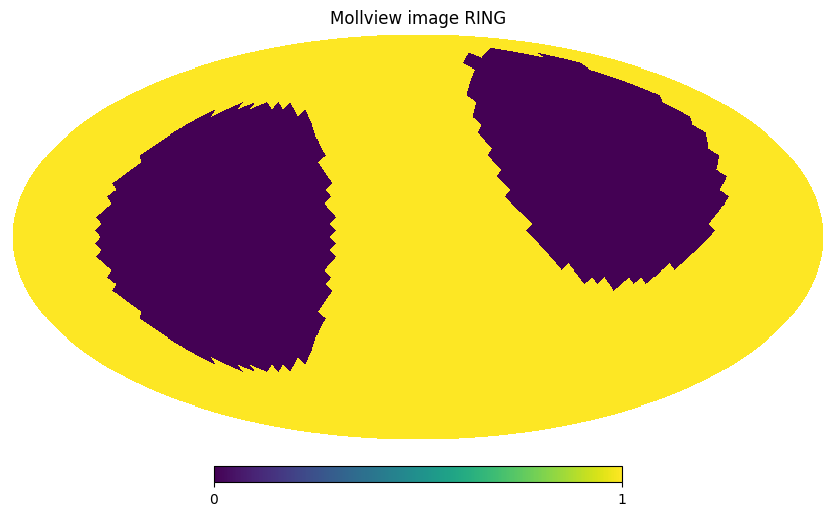

In [7]:
# let's generate a mask that covers ~65% of the sky
vec = hp.ang2vec(np.pi / 2, np.pi/2)
ipix_disc = hp.query_disc(nside=nside, vec=vec, radius=np.radians(51))
vec1 = hp.ang2vec(np.pi / 3, 3*np.pi/2)
ipix_disc1 = hp.query_disc(nside=nside, vec=vec1, radius=np.radians(47))

m = np.ones(hp.nside2npix(nside))
m[ipix_disc] = 0.
m[ipix_disc1]=0.
hp.mollview(m, title="Mollview image RING")
print(m.mean())

In [8]:
from utilities import *
from qmlfast import *
# we are going to construct the pixel-space covariance matrix for the masked sky.
def get_pix_cov_block(cl,Pl_ij,lmin,lmax):
    cov = oe.contract('ijk,i->jk',Pl_ij[lmin:lmax],cl[lmin:lmax])
    return cov
theta, phi = theta_phi(nside)
theta = theta[m==1]
phi = phi[m==1]
Pl_ij = get_Pl_ij(theta,phi,nside,lmax=3*nside-1)

In [9]:
def get_pix_cov_block(cl,Pl_ij,lmin,lmax):
    cov = oe.contract('ijk,i->jk',Pl_ij[lmin:lmax],cl[lmin:lmax])
    return cov

cov_a = get_pix_cov_block(S_aa,Pl_ij,0,3*nside-1)
cov_b = get_pix_cov_block(S_bb,Pl_ij,0,3*nside-1)
cov_c = get_pix_cov_block(S_cc,Pl_ij,0,3*nside-1)

cov_ab = get_pix_cov_block(S_ab, Pl_ij, 0, 3*nside-1)
cov_bc = get_pix_cov_block(S_bc, Pl_ij, 0, 3*nside-1)
cov_ca = get_pix_cov_block(S_ca, Pl_ij, 0, 3*nside-1)    

Np = cov_a.shape[0]
#fill up the large covariance matrix + add white noise
omega_pix = 4 * np.pi / hp.nside2npix(nside)

large_cov = np.zeros([3*Np,3*Np])

large_cov[block_np(0, 0, Np)] = cov_a + np.identity(cov_a.shape[0])*N_a/omega_pix
large_cov[block_np(0, 1, Np)] = cov_ab
large_cov[block_np(0, 2, Np)] = cov_ca

large_cov[block_np(1, 0, Np)] = large_cov[block_np(0, 1, Np)].T
large_cov[block_np(1, 1, Np)] = cov_b + np.identity(cov_b.shape[0])*N_b/omega_pix
large_cov[block_np(1, 2, Np)] = cov_bc

large_cov[block_np(2, 0, Np)] = large_cov[block_np(0, 2, Np)].T
large_cov[block_np(2, 1, Np)] = large_cov[block_np(1, 2, Np)].T
large_cov[block_np(2, 2, Np)] = cov_c + np.identity(cov_c.shape[0])*N_c/omega_pix

### Remove the multipoles with $\ell < \ell_{min}$
This block illustrates how to remove the unwanted multipoles. We start with constructing $Z$ and $\Pi$ matrices

In [10]:
ell0=4
Z, pi = construct_Z_and_pi(theta,phi,ell0=ell0,lmax=3*nside-1)

In [11]:
# we construct the pseudo-inverse, as described in 2.5 of the paper
import scipy as sp
for i in range(3):
    for j in range(3):
            block = large_cov[block_np(i,j,Np)]
            large_cov[block_np(i,j,Np)] = pi@block@pi.T   

eta=1e-1
M = np.linalg.inv(large_cov+eta*sp.linalg.block_diag(Z@Z.T,Z@Z.T,Z@Z.T))
for i in range(3):
    for j in range(3):
            block = M[block_np(i,j,Np)]
            M[block_np(i,j,Np)] = pi@block@pi.T          

### Calculate the Fisher
We first define the array of indexes of the Fisher matrix. It has the shape of (N,3) where N is the total number of power spectra. $$N=(\ell_{max})\times\frac{N_f(N_f+1)}{2}$$
The third column is always a multipole number, the first and second are field indices. The convention is always that the first field index greater than or equal to the second one:
$$ \texttt{F\_idx[:,0]} \leq  \texttt{F\_idx[:,1]} $$
Note that we are going to calculate the full Fisher (including the null block corresponding to the removed multiploles). It's a good sanity check to make sure that block is 0 afterwards

In [12]:
Nf = 3
F_idx = np.array([(i, j, l) for l in range(0, 3*nside) for i in range(Nf) for j in range(i, Nf)]) 
print(F_idx.shape)

(288, 3)


In [13]:
#Generate the array of real spherical harmonics of shape (lmax,2lmax-1,N_pix)
Y_r_all = sph_harm_y_real_all(3*nside,theta,phi)
print(Y_r_all.shape)

(48, 95, 2008)


The $\texttt{getF}$ function takes the following arguments:
 - the array of the spherical harmomics Y_r_all
 - the pseudo-inverse M
 - the array of Fisher indices F
 - the number of fields Nf and the number of pixels per field Np
 - C_map - the array that represents the block structure of the inverse covariance.
 In places where the inverse has zero blocks, C_map will contain zeros telling the main routine not to calculate the correspondent products and traces to save time.
 
 In our case of fully-dense covariance, it's just a $3\times3$ matrix of ones

In [14]:
C_map = np.ones([3,3])
F = getF(Y_r_all,M,F_idx,Nf,Np,C_map)

YCinvY: 100%|██████████| 6/6 [00:01<00:00,  3.93it/s]


Sanity check: the Fisher elements with $\ell < \ell_{min}$ have to be 0

In [15]:
np.all(np.abs(F[np.ix_(F_idx[:,2]<ell0,F_idx[:,2]<ell0)]) < 1e-25)

True

### Run simulations and compute the QML estimates

In [ ]:
ys = []
for i in tqdm(range(2500)):
    # Simulate the alms
    alm_a, alm_b, alm_c = hp.synalm([C_aa,C_ab,C_ca, C_bb,C_bc, C_cc], lmax=lmax) 
    x = np.stack([hp.alm2map(alm_a,nside)[m==1],
                  hp.alm2map(alm_b,nside)[m==1],
                  hp.alm2map(alm_c,nside)[m==1]])
    y = get_y(x, Y_r_all,M,F_idx,Nf,Np)
    ys.append(y)

 35%|███▌      | 883/2500 [00:43<00:48, 33.41it/s]

In [17]:
#remove the null block
ys = np.array(ys)[:, F_idx[:,2]>=ell0]
F = F[np.ix_(F_idx[:,2]>=ell0, F_idx[:,2]>=ell0)]
#get the inverse of the Fisher matrix
invF = np.linalg.inv(F)
#get the qml estimates by multiplying by the inverse fisher matrix
es = ys@invF
e_mean = es.mean(axis=0)
err_analytic = invF
err_empirical = np.cov(es,rowvar=False,ddof=0)
f_idx = F_idx[F_idx[:,2]>=ell0]


### Plot the resulting estimates for the auto and cross spectra

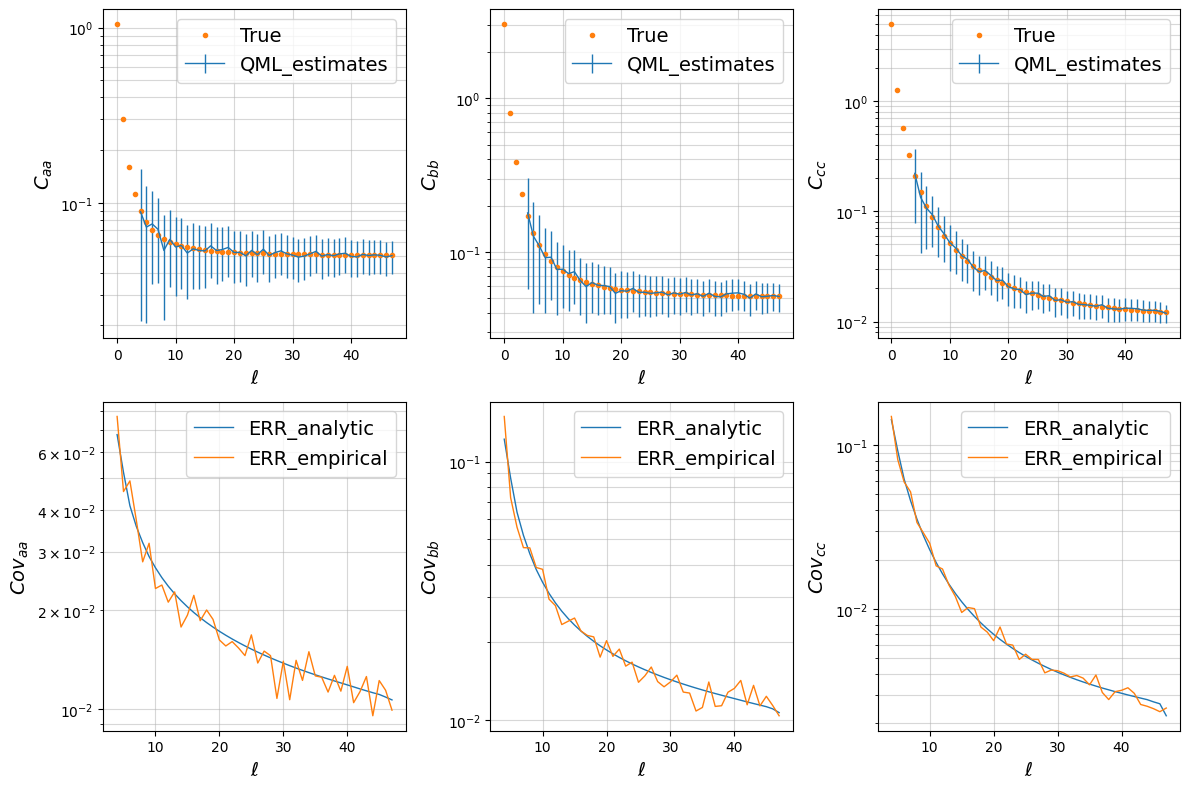

In [18]:
fig, axs = plt.subplots(2,3,figsize=(12,8))

idx_a = (f_idx[:,0]==0)*(f_idx[:,1]==0)

axs[0,0].errorbar(np.arange(ell0,3*nside),e_mean[idx_a],yerr=np.sqrt(err_analytic[idx_a,idx_a]),lw=1,label='QML_estimates')
axs[0,0].semilogy(np.arange(len(C_aa)),C_aa,'.',label='True')
axs[0,0].set_xlabel(r'$\ell$', fontsize=14)
axs[0,0].set_ylabel(r'$C_{aa}$', fontsize=14)
axs[0,0].legend(fontsize=14)
axs[0,0].grid(which='both', alpha=0.5)

axs[1,0].semilogy(np.arange(ell0,3*nside),np.sqrt(err_analytic[idx_a,idx_a]),lw=1,label='ERR_analytic')
axs[1,0].semilogy(np.arange(ell0,3*nside),np.sqrt(err_empirical[idx_a,idx_a]),lw=1,label='ERR_empirical')
axs[1,0].set_xlabel(r'$\ell$', fontsize=14)
axs[1,0].set_ylabel(r'$Cov_{aa}$', fontsize=14)
axs[1,0].legend(fontsize=14)
axs[1,0].grid(which='both', alpha=0.5)


idx_b = (f_idx[:,0]==1)*(f_idx[:,1]==1)
axs[0,1].errorbar(np.arange(ell0,3*nside),e_mean[idx_b],yerr=np.sqrt(err_analytic[idx_b,idx_b]),lw=1,label='QML_estimates')
axs[0,1].semilogy(np.arange(len(C_bb)),C_bb,'.',label='True')
axs[0,1].set_xlabel(r'$\ell$', fontsize=14)
axs[0,1].set_ylabel(r'$C_{bb}$', fontsize=14)
axs[0,1].legend(fontsize=14)
axs[0,1].grid(which='both', alpha=0.5)
axs[1,1].semilogy(np.arange(ell0,3*nside),np.sqrt(err_analytic[idx_b,idx_b]),lw=1,label='ERR_analytic')
axs[1,1].semilogy(np.arange(ell0,3*nside),np.sqrt(err_empirical[idx_b,idx_b]),lw=1,label='ERR_empirical')
axs[1,1].set_xlabel(r'$\ell$', fontsize=14)
axs[1,1].set_ylabel(r'$Cov_{bb}$', fontsize=14)
axs[1,1].legend(fontsize=14)
axs[1,1].grid(which='both', alpha=0.5)

idx_c = (f_idx[:,0]==2)*(f_idx[:,1]==2)
axs[0,2].errorbar(np.arange(ell0,3*nside),e_mean[idx_c],yerr=np.sqrt(err_analytic[idx_c,idx_c]),lw=1,label='QML_estimates')
axs[0,2].semilogy(np.arange(len(C_cc)),C_cc,'.',label='True')
axs[0,2].set_xlabel(r'$\ell$', fontsize=14)
axs[0,2].set_ylabel(r'$C_{cc}$', fontsize=14)
axs[0,2].legend(fontsize=14)
axs[0,2].grid(which='both', alpha=0.5)

axs[1,2].semilogy(np.arange(ell0,3*nside),np.sqrt(err_analytic[idx_c,idx_c]),lw=1,label='ERR_analytic')
axs[1,2].semilogy(np.arange(ell0,3*nside),np.sqrt(err_empirical[idx_c,idx_c]),lw=1,label='ERR_empirical')
axs[1,2].set_xlabel(r'$\ell$', fontsize=14)
axs[1,2].set_ylabel(r'$Cov_{cc}$', fontsize=14)
axs[1,2].legend(fontsize=14)
axs[1,2].grid(which='both', alpha=0.5)

plt.tight_layout()

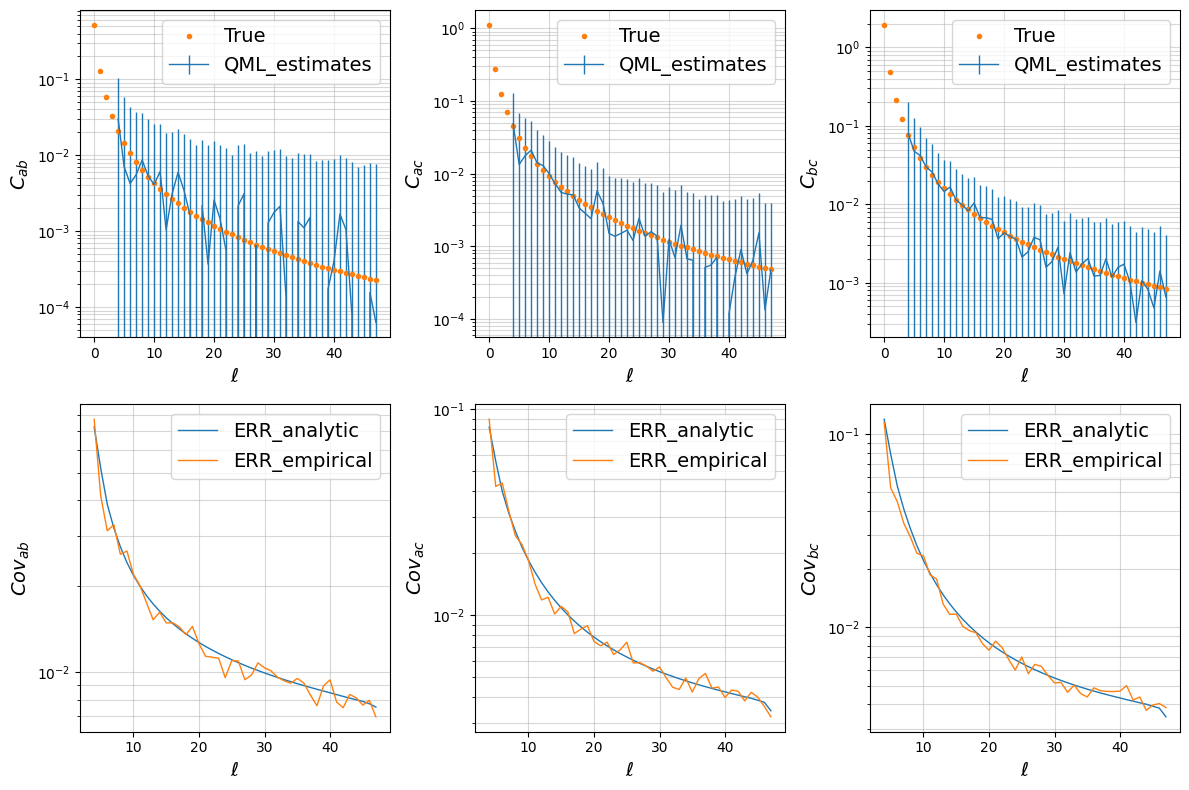

In [19]:
# Plot cross spectra
fig, axs = plt.subplots(2,3,figsize=(12,8))

# C_ab: first field 0, second field 1
idx_ab = (f_idx[:,0]==0)*(f_idx[:,1]==1)

axs[0,0].errorbar(np.arange(ell0,3*nside),e_mean[idx_ab],yerr=np.sqrt(err_analytic[idx_ab,idx_ab]),lw=1,label='QML_estimates')
axs[0,0].semilogy(np.arange(len(C_ab)),C_ab,'.',label='True')
axs[0,0].set_xlabel(r'$\ell$', fontsize=14)
axs[0,0].set_ylabel(r'$C_{ab}$', fontsize=14)
axs[0,0].legend(fontsize=14)
axs[0,0].grid(which='both', alpha=0.5)

axs[1,0].semilogy(np.arange(ell0,3*nside),np.sqrt(err_analytic[idx_ab,idx_ab]),lw=1,label='ERR_analytic')
axs[1,0].semilogy(np.arange(ell0,3*nside),np.sqrt(err_empirical[idx_ab,idx_ab]),lw=1,label='ERR_empirical')
axs[1,0].set_xlabel(r'$\ell$', fontsize=14)
axs[1,0].set_ylabel(r'$Cov_{ab}$', fontsize=14)
axs[1,0].legend(fontsize=14)
axs[1,0].grid(which='both', alpha=0.5)

# C_ac: first field 0, second field 2
idx_ac = (f_idx[:,0]==0)*(f_idx[:,1]==2)

axs[0,1].errorbar(np.arange(ell0,3*nside),e_mean[idx_ac],yerr=np.sqrt(err_analytic[idx_ac,idx_ac]),lw=1,label='QML_estimates')
axs[0,1].semilogy(np.arange(len(C_ca)),C_ca,'.',label='True')
axs[0,1].set_xlabel(r'$\ell$', fontsize=14)
axs[0,1].set_ylabel(r'$C_{ac}$', fontsize=14)
axs[0,1].legend(fontsize=14)
axs[0,1].grid(which='both', alpha=0.5)

axs[1,1].semilogy(np.arange(ell0,3*nside),np.sqrt(err_analytic[idx_ac,idx_ac]),lw=1,label='ERR_analytic')
axs[1,1].semilogy(np.arange(ell0,3*nside),np.sqrt(err_empirical[idx_ac,idx_ac]),lw=1,label='ERR_empirical')
axs[1,1].set_xlabel(r'$\ell$', fontsize=14)
axs[1,1].set_ylabel(r'$Cov_{ac}$', fontsize=14)
axs[1,1].legend(fontsize=14)
axs[1,1].grid(which='both', alpha=0.5)

# C_bc: first field 1, second field 2
idx_bc = (f_idx[:,0]==1)*(f_idx[:,1]==2)

axs[0,2].errorbar(np.arange(ell0,3*nside),e_mean[idx_bc],yerr=np.sqrt(err_analytic[idx_bc,idx_bc]),lw=1,label='QML_estimates')
axs[0,2].semilogy(np.arange(len(C_bc)),C_bc,'.',label='True')
axs[0,2].set_xlabel(r'$\ell$', fontsize=14)
axs[0,2].set_ylabel(r'$C_{bc}$', fontsize=14)
axs[0,2].legend(fontsize=14)
axs[0,2].grid(which='both', alpha=0.5)

axs[1,2].semilogy(np.arange(ell0,3*nside),np.sqrt(err_analytic[idx_bc,idx_bc]),lw=1,label='ERR_analytic')
axs[1,2].semilogy(np.arange(ell0,3*nside),np.sqrt(err_empirical[idx_bc,idx_bc]),lw=1,label='ERR_empirical')
axs[1,2].set_xlabel(r'$\ell$', fontsize=14)
axs[1,2].set_ylabel(r'$Cov_{bc}$', fontsize=14)
axs[1,2].legend(fontsize=14)
axs[1,2].grid(which='both', alpha=0.5)

plt.tight_layout()
